In [1]:
from math import exp, sqrt, sin, cos
import itertools
import csv
from tqdm import tqdm_notebook

import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as integrate
from scipy.optimize import fsolve, curve_fit


In [2]:
def read_to_array(name):
    with open(name, newline="") as csvfile:
        data = list(csv.reader(csvfile))
    return np.array(data).astype(float)

In [3]:
def arrays_to_csv(array1, array2, name):
    with open(f"{name}.csv", "w", newline="") as file:
        writer = csv.writer(file)
        for a1, a2 in zip(array1, array2):
            writer.writerow([round(a1, 5), a2])

## Konstante i osnovne funkcije

In [4]:
kb = 8.6173303 * 10 ** (-5)
hbar = 6.582119569 * 10 ** (-16)
pi = np.pi
c = 3*10**8
m = 0.511 / c**2 *10 **6
e = 1.602 * 10 ** (-19)

alpha_op = 0.12
alpha_ac = 0.2
hbar_op = 0.02
c_s_tilde = 0.0498  # hbar_w_ac / hbar / vf * a
eta_0 = 1 * 10 ** (-3) # Sigma_dis
Eta_0 = 1 * 10 ** (-3) # Gamma_dis
M = 0.0
Kf_20 = 0.26  # eV, Fermi 20K
vf = 4 * 10**5
a = 100 ** (1 / 3) * 10 ** (-10)
T_0 = 20
Kf_max_ev = 1 # 1eV cutoff


Ef = sqrt(Kf_20**2 + M**2)
Kf_ = Kf_20 / hbar / vf * a  # Fermi unitless
Kf_max = Kf_max_ev / hbar / vf * a  # cutoff 1eV unitless
hbar_w_ac_max = c_s_tilde * hbar * vf / a
G_op2 = alpha_op
G_ac2 = alpha_ac * hbar * vf / a

In [5]:
def fermi_dirac(E, Ef, T):
    if T > 0:
        if E > Ef:
            return exp((-E + Ef) / (kb * T)) / (exp((-E + Ef) / (kb * T)) + 1)
        else:
            return 1 / (exp((E - Ef) / (kb * T)) + 1)
    else:
        if E > Ef:
            return 0
        else:
            return 1


def d_fermi_dirac(E, Ef, T):
    return 1 / kb / T * fermi_dirac(E, Ef, T) * (1 - fermi_dirac(E, Ef, T))


def bose_einstein(E, T):
    if T == 0:
        return 0
    return exp(-E / (kb * T)) / (-exp(-E / (kb * T)) + 1)


def chemical_potential(T):
    #return (
    #    Ef
    #    - pi**2 / 6 * (2 * Ef**2 - M**2) / Ef / (Ef**2 - M**2) * (kb * T) ** 2
    #    - 7 / 360 * pi**4 * 3 * M**4 / Ef / (Ef**2 - M**2) ** 3 * (kb * T) ** 4
    #)  # Sommerfield approx.


    return abs(fsolve(particle_density_int, 0.55, args=(M,Kf_20,T))[0]) # use this for exact value


def particle_density(E, Ef, M, T):
    g = E * sqrt(E**2 - M**2) / pi**2 / (hbar * vf) ** 3
    fs = -fermi_dirac(E, -Ef, T) + fermi_dirac(E, Ef, T)
    return g * fs


def particle_density_int(u, M, Kf, T):
    na = 1 / 3 / pi**2 * Kf**3 / (vf * hbar) ** 3
    return na - integrate.quad(particle_density, M, 7, args=(u, M, T), limit=80000)[0]


def eps(K):
    return sqrt(hbar**2 * vf**2 / a**2 * K**2 + M**2)  # K dimensionless


def eff_concetration(T):
    def integrand(k):
        return 2 / hbar / vf / a**2 * fermi_dirac(eps(k), chemical_potential(T), T) * k

    return (
        4
        * pi
        / 3
        * 2
        / (2 * pi) ** 3
        * vf**2
        * integrate.quad(integrand, 0, Kf_max, limit=80000)[0]
    )

In [6]:
print(eff_concetration(0)*a**3*m*10**3)  # T=0 numerički
print(4 * pi / 3 * 2 / (2 * pi) ** 3 * Kf_20**2 / hbar**3 / vf*a**3*m*10**3)  # T=0 analitički

11.364407374751996
11.364407374660376


In [7]:
print(1/3/pi**2/hbar**3*Kf_20**3/vf**3) # nositelji naboja

3.2525334218083763e+25


In [8]:
d_fermi_dirac(eps(Kf_ - 0.0000005), eps(Kf_), 0.001)

401363.8029352404

In [6]:
ws_0 = np.arange(0.0001, 0.1001, 0.001)


def calculate_integral_points(
    mem_fn, real_sum, imag_sum, hbar_w_ph, T=T_0, eta=eta_0, ws=ws_0, u=Kf_20
):

    result_real = []

    result_imag = []

    for w in tqdm_notebook(ws):

        result_real.append(
            mem_fn(
                real_sum,
                w,
                hbar_w_ph,
                u,
                T=T,
                eta=eta,
            )
        )

        result_imag.append(
            mem_fn(
                imag_sum,
                w,
                hbar_w_ph,
                u,
                T=T,
                eta=eta,
            )
        )

    return result_real, result_imag


def setup_plot(real=True, imag=True, x_lim=[0.0, 0.05], y_lim=[0, 0.06]):

    fig, ax1 = plt.subplots()

    ax1.set_xlabel(r"$\hbar \omega [eV]$")

    if real:

        ax1.set_ylabel(r"$\hbar Re\{M_z\} [eV]$")

    else:

        ax1.set_ylabel(r"$\hbar Im\{M_z\} [eV]$")

    ax1.set_xlim(x_lim)

    ax1.set_ylim(y_lim)

    ax2 = ax1.twinx()

    if imag and real:

        ax2.set_ylabel(r"$\hbar Im\{M_z\} [eV]$")

    ax2.set_xlim(x_lim)

    ax2.set_ylim(y_lim)

    return fig, ax1, ax2


def plot_real_and_imag_result(
    ax1, ax2, result_real, result_imag, T=None, eta=None, ws=ws_0
):
    assert T or eta

    ax1.plot(ws, result_real, label=f"T={T} K" if T else f"$\eta = $ {eta:.4f} eV")

    ax2.plot(ws, result_imag)

    if T:

        plt.text(0.020, 0.002, f"$\eta = $ {eta_0:.4f} $eV$", fontsize=10)

    else:

        plt.text(0.020, 0.002, f"T={T_0} K", fontsize=10)


def plot_result(ax, result, T=None, eta=None, ws=ws_0):

    ax.plot(ws, result, label=f"T={T} K" if T else f"$\eta = $ {eta:.5f} eV")

## Optički fononi


**Memorijska funkcija**

In [10]:
def ss_sum_part(K, hbar_w, hbar_w_ph, T, u, eta):
    def summand(s1, s2):
        return (
            bose_einstein(hbar_w_ph, T) + fermi_dirac(s1 * s2 * eps(K), s1 * s2 * u, T)
        ) / (hbar_w + s1 * Ef - s1 * eps(K) + s2 * hbar_w_ph + eta * 1j)

    sum = 0
    for s1, s2 in itertools.product([-1, 1], [-1, 1]):
        sum = sum + summand(s1, s2)
    return sum * K**2


def ss_sum_real(K, hbar_w, hbar_w_ph, T, u, eta):
    return ss_sum_part(K, hbar_w, hbar_w_ph, T, u, eta).real


def ss_sum_imag(K, hbar_w, hbar_w_ph, T, u, eta):
    return ss_sum_part(K, hbar_w, hbar_w_ph, T, u, eta).imag


def mem_fn_op(ss_sum_fn, hbar_w, hbar_w_ph, u, T, eta):
    integral_k = integrate.quad(
        ss_sum_fn, 0, Kf_max, args=(hbar_w, hbar_w_ph, T, u, eta), limit=80000
    )[0]
    return (
        -G_op2 * integral_k / (2 * pi) ** 2 * 2
    )  # one factor 2 for 4\pi and one for two bands

C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\2621571283.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

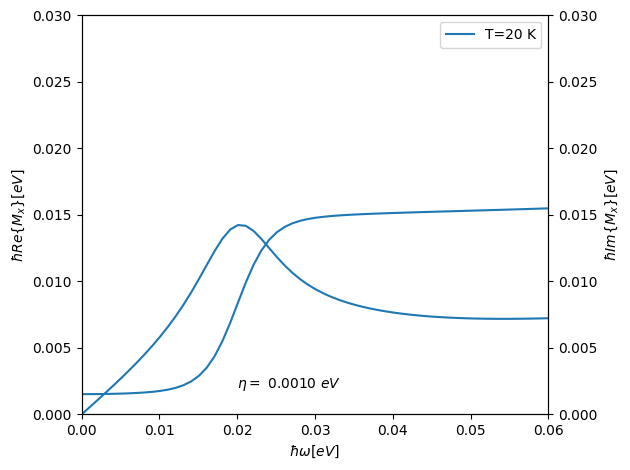

In [10]:
fig, *axs = setup_plot(x_lim=[0, 0.06], y_lim=[0, 0.03])
integrals = calculate_integral_points(
    mem_fn_op, ss_sum_real, ss_sum_imag, hbar_w_ph=hbar_op, T=T_0
)
# arrays_to_csv(ws_0, integrals[0], f"op, real, T={T_0}K, eta={eta_0}eV")
# arrays_to_csv(ws_0, integrals[1], f"op, imag, T={T_0}K, eta={eta_0}eV")
plot_real_and_imag_result(*axs, integrals[0], np.array(integrals[1])+np.full_like(np.array(integrals[1]), Eta_0), T=T_0)
axs[0].legend(loc="best")
fig.tight_layout()

C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\4288499314.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return exp((-E + Ef) / (kb * T)) / (exp((-E + Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\4288499314.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (exp((E - Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\2621571283.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

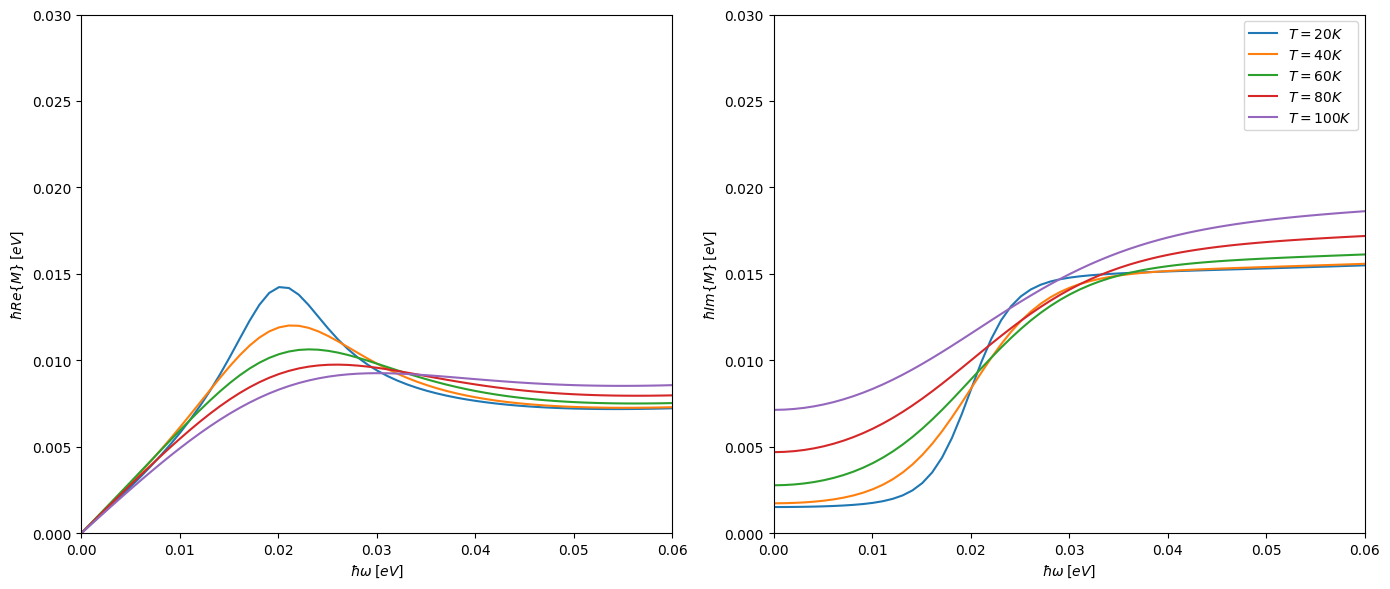

In [16]:
fig, axs = plt.subplots(ncols=2,figsize=(14,6))
for T in [20, 40, 60, 80, 100]:
    integrals = calculate_integral_points(
        mem_fn_op,
        ss_sum_real,
        ss_sum_imag,
        hbar_op,
        T=T,
        u=chemical_potential(T),
    )
    axs[0].plot(ws_0, integrals[0])
    imag = np.array(integrals[1])+np.full_like(np.array(integrals[1]), Eta_0)
    axs[1].plot(ws_0, imag, label=f"$T={T} K$")
    arrays_to_csv(ws_0, integrals[0], f"optical_memory_fn_real_T={T}K")
    arrays_to_csv(ws_0, imag, f"optical_memory_fn_imag_T={T}K")
axs[1].legend(loc="best")
y_lim=[0, 0.03]
x_lim=[0, 0.06]
axs[0].set_xlim(x_lim)
axs[0].set_ylim(y_lim)
axs[1].set_xlim(x_lim)
axs[1].set_ylim(y_lim)
axs[0].set_ylabel(r"$\hbar Re\{M\}\: [eV]$")
axs[1].set_ylabel(r"$\hbar Im\{M\}\: [eV]$")
axs[0].set_xlabel(r"$\hbar \omega \: [eV]$")
axs[1].set_xlabel(r"$\hbar \omega \: [eV]$")
# plt.text(0.020, 0.002, f"$\eta = $ {eta_0:.4f} $eV$", fontsize=10)
fig.tight_layout()

## Akustični fononi

In [11]:
def ss_sum_part_ac(K, theta, hbar_w, hbar_w_ph, T, u, eta):
    def summand(s1, s2):
        abs_K = sqrt(K**2 + Kf_**2 - 2 * Kf_ * K * cos(theta))
        factor = 1 - K * cos(theta) * Ef / eps(K) / Kf_
        return (
            (
                bose_einstein(hbar_w_ph * abs_K, T)
                + fermi_dirac(s1 * s2 * eps(K), s1 * s2 * u, T)
            )
            / (hbar_w + s1 * Ef - s1 * eps(K) + s2 * hbar_w_ph * abs_K + eta * 1j)
            * abs_K
            * factor
        )

    sum = 0
    for s1, s2 in itertools.product([-1, 1], [-1, 1]):
        sum = sum + summand(s1, s2)
    return sum * K**2 * sin(theta)


def ss_sum_real_ac(K, theta, hbar_w, hbar_w_ph, T, u, eta):
    return ss_sum_part_ac(K, theta, hbar_w, hbar_w_ph, T, u, eta).real


def ss_sum_imag_ac(K, theta, hbar_w, hbar_w_ph, T, u, eta):
    return ss_sum_part_ac(K, theta, hbar_w, hbar_w_ph, T, u, eta).imag


def mem_fn_ac(ss_sum_fn, hbar_w, hbar_w_ph, u, T, eta):
    integral_k_theta = integrate.nquad(
        ss_sum_fn,
        ([0, Kf_max], [0, pi]),
        args=(hbar_w, hbar_w_ph, T, u, eta),
        opts={"epsabs": 1.49 * 10 ** (-4), "epsrel": 1.49 * 10 ** (-4)},
    )[0]
    return -G_ac2 * integral_k_theta / (2 * pi) ** 2

**Memorijska funkcija**

C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\4288499314.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return exp((-E + Ef) / (kb * T)) / (exp((-E + Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\4288499314.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (exp((E - Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\2663874110.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

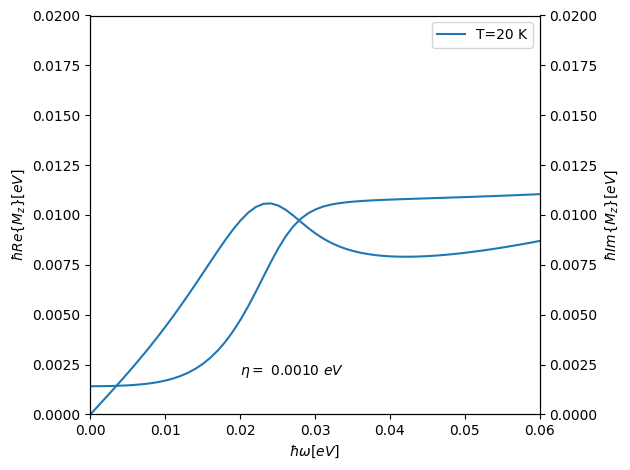

In [27]:
fig, *axs = setup_plot(x_lim=[0, 0.06], y_lim=[0, 0.02])
integrals = calculate_integral_points(
    mem_fn_ac, ss_sum_real_ac, ss_sum_imag_ac, hbar_w_ac_max, T=T_0, eta=eta_0, u = chemical_potential(T=T_0)
)
plot_real_and_imag_result(*axs, integrals[0], np.array(integrals[1])+np.full_like(np.array(integrals[1]), Eta_0), T=20)
# arrays_to_csv(ws_0, integrals[0], f"ac, real, T=20K, eta={eta_0}eV")
# arrays_to_csv(ws_0, integrals[1], f"ac, imag, T=20K, eta={eta_0}eV")
axs[0].legend(loc="best")
fig.tight_layout()

C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\4288499314.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return exp((-E + Ef) / (kb * T)) / (exp((-E + Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\4288499314.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (exp((E - Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\2663874110.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\Patrik\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

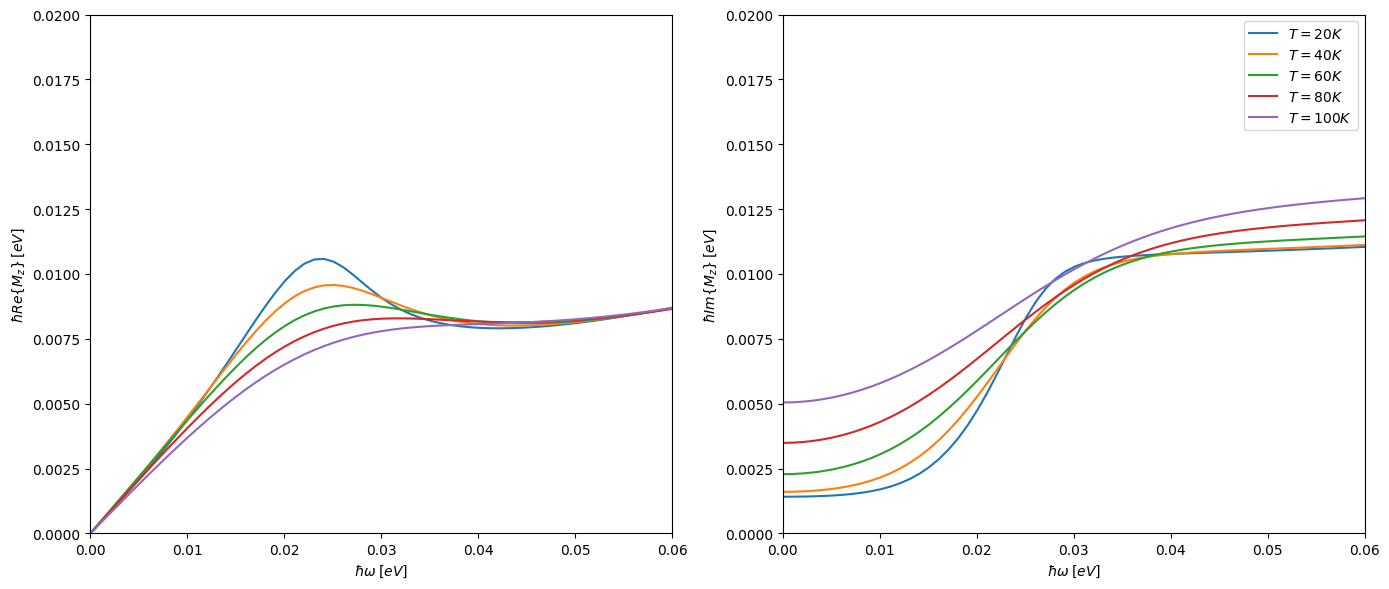

In [28]:
fig, axs = plt.subplots(ncols=2,figsize=(14,6))
for T in [20, 40, 60, 80, 100]:
    integrals = calculate_integral_points(
        mem_fn_ac,
        ss_sum_real_ac,
        ss_sum_imag_ac,
        hbar_w_ac_max,
        T=T,
        u=chemical_potential(T),
    )
    axs[0].plot(ws_0, integrals[0])
    imag = np.array(integrals[1])+np.full_like(np.array(integrals[1]), Eta_0)
    axs[1].plot(ws_0, imag, label=f"$T={T} K$")
    arrays_to_csv(ws_0, integrals[0], f"acoustic_memory_fn_real_T={T}K")
    arrays_to_csv(ws_0, imag, f"acoustic_memory_fn_imag_T={T}K")
axs[1].legend(loc="best")
y_lim=[0, 0.02]
x_lim=[0, 0.06]
axs[0].set_xlim(x_lim)
axs[0].set_ylim(y_lim)
axs[1].set_xlim(x_lim)
axs[1].set_ylim(y_lim)
axs[0].set_ylabel(r"$\hbar Re\{M_z\}\: [eV]$")
axs[1].set_ylabel(r"$\hbar Im\{M_z\}\: [eV]$")
axs[0].set_xlabel(r"$\hbar \omega \: [eV]$")
axs[1].set_xlabel(r"$\hbar \omega \: [eV]$")
# plt.text(0.020, 0.002, f"$\eta = $ {eta_0:.4f} $eV$", fontsize=10)
fig.tight_layout()

**Provjera**

In [ ]:
import pandas as pd 
kup = pd.read_csv("080325_provjera//kup_20k_re.txt", header=None)
plt.plot(list(kup[0]),list(kup[1]), label="K")
plt.plot(ws_0[:60],np.array(integrals[0][:60])*1000, label = "P", linestyle = "--")
plt.ylabel("$M_1(\omega)$")
plt.legend()
plt.show()

kup_im = pd.read_csv("080325_provjera//kup_20k_im.txt", header=None)
plt.plot(list(kup_im[0]),list(kup_im[1]), label="K")
full_mem_im = np.array(integrals[1][:60])*1000
full_mem_im = full_mem_im + np.full_like(full_mem_im, Eta_0*1000)
plt.plot(ws_0[:60], full_mem_im, label = "P",linestyle="--")
plt.ylabel("$M_2(\omega)$")
plt.legend()
plt.show()

In [ ]:
kup_100 = pd.read_csv("kupcic_100k_re.txt", header=None)
plt.plot(list(kup_100[0]),list(kup_100[1]), label="K")
plt.plot(ws_0[:60],np.array(integrals_100[0][:60])*1000, label = "P", linestyle="--")
plt.legend()
plt.ylabel("$M_1(\omega)$")
plt.show()
kup_100_im = pd.read_csv("kupcic_100k_im.txt", header=None)
plt.plot(list(kup_100_im[0]),list(kup_100_im[1]), label="K")
full_mem_im_100 = np.array(integrals_100[1][:60])*1000
full_mem_im_100 = full_mem_im_100 + np.full_like(full_mem_im_100, Eta_0*1000)
plt.plot(ws_0[:60], full_mem_im_100, label = "P", linestyle="--")
plt.ylabel("$M_2(\omega)$")
plt.legend()
plt.show()

**Fit $M_2$**

In [30]:
Ts = np.linspace(0.0001, 1000, 10000)


def M_T_dep(c_s, eta):
    res_real = []
    res_imag = []
    hbar_w_ac_ = c_s * hbar * vf / a
    for T in Ts:
        res_real.append(
            mem_fn_ac(
                ss_sum_real_ac, 0, hbar_w_ac_, u=chemical_potential(T), T=T, eta=eta
            )
        )
        res_imag.append(
            mem_fn_ac(
                ss_sum_imag_ac, 0, hbar_w_ac_, u=chemical_potential(T), T=T, eta=eta
            )
        )
        arrays_to_csv(Ts, res_real, f"M(T) real, ac, eta={eta}eV, c_s_tilde={c_s}")
        arrays_to_csv(Ts, res_imag, f"M(T) imag, ac, eta={eta}eV, c_s_tilde={c_s}")
    return res_real, res_imag

In [81]:
for c_s in [0.03, 0.025, 0.02]:
    M_T_dep(c_s, eta_0)

In [ ]:
fig, ax = plt.subplots()
colors = ["y", "g", "r"]
cnt = 0
for c_s, T_1, T_2 in zip([0.03, 0.025, 0.02], [50, 40, 30], [70, 60, 50]):
    c = colors[cnt]
    cnt = cnt + 1

    res = read_to_array(
        f"28052025_dirac3d_1/M(T) imag, ac, eta={eta_0}eV, c_s_tilde={c_s}.csv"
    )
    ax.plot(
        Ts[:10000:5],
        res[:, 1][:10000:5],
        label=f"$c_s={c_s}$ eV, $T_1={T_1}$ K, $T_2={T_2}$ K",
        color=c,
    )
    ax.annotate(
        "",
        xy=(T_1, 0.00),
        xytext=(T_1, -0.01),
        arrowprops=dict(
            arrowstyle="->",
            color=c,
            lw=0.5,
        ),
    )
plt.ylim([0, 0.1])
plt.xlim([0, 100])
plt.text(32, -0.012, "$T_1$")
ax.tick_params(top=True, right=True, labelright=True, labeltop=True, which="both")
ax.minorticks_on()
ax.grid(which="both", alpha=0.2)

plt.legend()

In [32]:
def function_to_fit(T, b, a, x):
    return b + a * T**x

In [ ]:
fit_results = []
for c_s, T_1 in zip([0.03, 0.025, 0.02], [50, 40, 30]):

    results = read_to_array(
        f"28052025_dirac3d_1/M(T) imag, ac, eta={eta_0}eV, c_s_tilde={c_s}.csv"
    )

    x_data = results[:, 0][: T_1 * 10]

    y_data = results[:, 1][: T_1 * 10]

    fit_results.append(
        curve_fit(f=function_to_fit, xdata=x_data, ydata=y_data, p0=[0.01, 0, 2.5])[0]
    )

In [164]:
table = {
    "c_s_tilde": [0.03, 0.025, 0.02],
    "T_1": [50, 40, 30],
    "T_2": [70, 60, 50],
    "b": [fit_results[i][0] for i in range(3)],
    "a": [fit_results[i][1] for i in range(3)],
    "x": [fit_results[i][2] for i in range(3)],
}
table = pd.DataFrame(table)
table

,c_s_tilde,T_1,T_2,b,a,x
0,0.030,50,70,0.014522,3.192147e-07,2.671436
1,0.025,40,60,0.016676,4.733957e-07,2.690343
2,0.020,30,50,0.019621,7.075701e-07,2.736824


In [166]:
for i, T_1 in enumerate([50, 40, 30]):
    ax.plot(
        Ts[:500],
        [
            function_to_fit(T, fit_results[i][0], fit_results[i][1], fit_results[i][2])
            for T in Ts[:500]
        ],
        color="black",
        linestyle="--",
        linewidth=0.8,
    )

# Drudeova formula

In [12]:
def Gamma_for_m_values(w_vals, m1_vals, m2_vals):
    m2_vals_ = np.array(m2_vals)
    m2_vals_ = m2_vals + np.full_like(m2_vals, Eta_0)
    def Gamma(w, m1, m2):
        return m2/(1+m1/w)
    return [10**3*Gamma(w,m1,m2) for w,m1,m2 in zip(w_vals,m1_vals,m2_vals_)]

def lambda_for_m_values(w_vals, m1_vals):
    return [m1/w for w,m1 in zip(w_vals,m1_vals)]

**Optički $\Gamma , \lambda$**


C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\2663874110.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

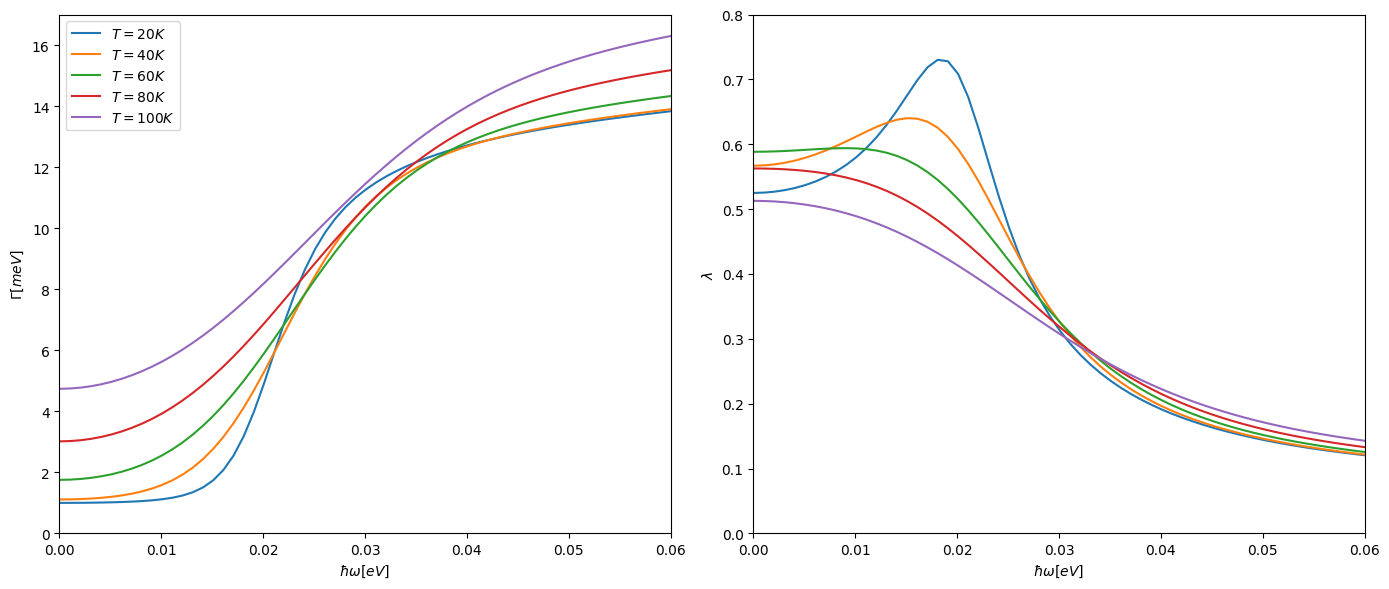

In [25]:
fig, axs = plt.subplots(ncols=2, figsize=(14,6))
for T in [20, 40, 60, 80, 100]:
    mem = calculate_integral_points(mem_fn_op, ss_sum_real, ss_sum_imag, hbar_op, T=T)
    gamma = Gamma_for_m_values(ws_0, m1_vals=mem[0], m2_vals=mem[1])
    lambdas = lambda_for_m_values(ws_0, mem[0])
    axs[0].plot(ws_0,gamma, label=f"$T={T} K$")
    axs[1].plot(ws_0, lambdas)
    arrays_to_csv(ws_0, gamma, f"optical_gamma_fn_T={T}K")
    arrays_to_csv(ws_0, lambdas, f"optical_lambda_fn_imag_T={T}K")
    
axs[0].set_xlabel(r"$\hbar \omega [eV]$")
axs[1].set_xlabel(r"$\hbar \omega [eV]$")
axs[0].set_xlim([0, 0.06])
axs[0].set_ylim([0, 17])
axs[1].set_xlim([0, 0.06])
axs[1].set_ylim([0, 0.8])
axs[0].set_ylabel(r"$\Gamma [meV]$")
axs[1].set_ylabel(r"$\lambda $")
axs[0].legend(loc="best")
fig.tight_layout()

**Akustični $\Gamma , \lambda $**

C:\Users\Patrik\AppData\Local\Temp\ipykernel_25416\2663874110.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\Patrik\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

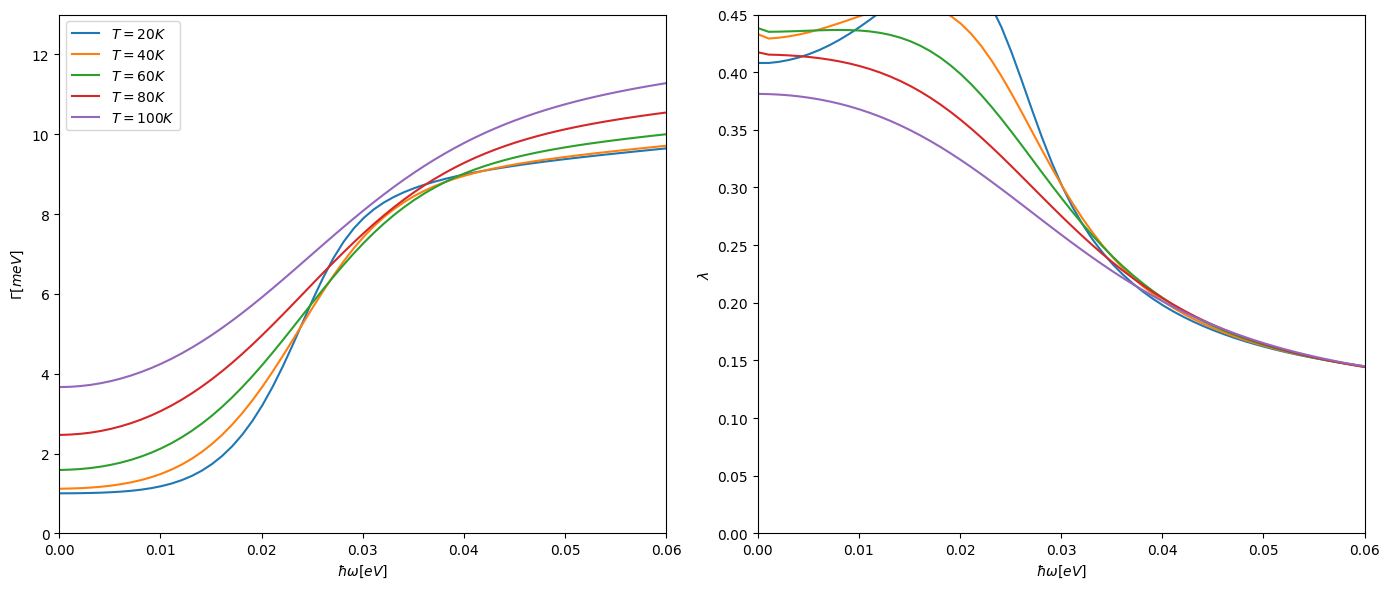

In [ ]:
fig, axs = plt.subplots(ncols=2, figsize=(14,6))
for T in [20, 40, 60, 80, 100]:
    mem = calculate_integral_points(mem_fn_ac, ss_sum_real_ac, ss_sum_imag_ac, hbar_w_ac_max, T=T)
    gamma = Gamma_for_m_values(ws_0, m1_vals=mem[0], m2_vals=mem[1])
    lambdas = lambda_for_m_values(ws_0, mem[0])
    axs[0].plot(ws_0,gamma, label=f"$T={T} K$")
    axs[1].plot(ws_0, lambdas)
    arrays_to_csv(ws_0, gamma, f"acoustic_gamma_fn_T={T}K")
    arrays_to_csv(ws_0, lambdas, f"acoustic_lambda_fn_imag_T={T}K")
axs[0].set_xlabel(r"$\hbar \omega [eV]$")
axs[1].set_xlabel(r"$\hbar \omega [eV]$")
axs[0].set_xlim([0, 0.06])
axs[0].set_ylim([0, 13])
axs[1].set_xlim([0, 0.06])
axs[1].set_ylim([0, 0.5])
axs[0].set_ylabel(r"$\Gamma [meV]$")
axs[1].set_ylabel(r"$\lambda $")
axs[0].legend(loc="best")
fig.tight_layout()

**Fit $\Gamma $**

In [34]:
Ts = np.linspace(0.0001, 150, 300)

def G_T_dep(c_s, eta):
    res_real = []
    res_imag = []
    hbar_w_ac_ = c_s * hbar * vf / a
    for T in tqdm_notebook(Ts):
        res_real.append(
            mem_fn_ac(
                ss_sum_real_ac, 0.0001, hbar_w_ac_, u=chemical_potential(T), T=T, eta=eta
            )
        )
        res_imag.append(
            mem_fn_ac(
                ss_sum_imag_ac, 0, hbar_w_ac_, u=chemical_potential(T), T=T, eta=eta
            )+Eta_0
        )
        # arrays_to_csv(Ts, res_real, f"M(T) real, ac, eta={eta}eV, c_s_tilde={c_s}")
        # arrays_to_csv(Ts, res_imag, f"M(T) imag, ac, eta={eta}eV, c_s_tilde={c_s}")
    res = [m2/(m1/0.0001+1) for m1,m2 in zip(res_real,res_imag)]
    arrays_to_csv(Ts, res, f"Gamma(T), eta={eta}eV, c_s_tilde={c_s}")
    return res

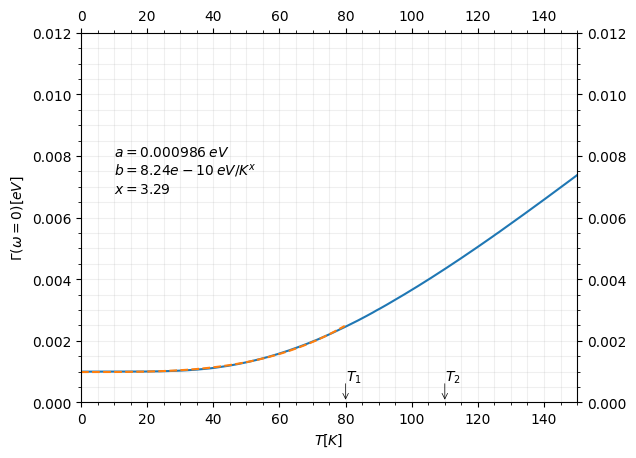

In [49]:
#gammas_0 = G_T_dep(c_s=c_s_tilde, eta=eta_0)
plt.plot(Ts, gammas_0)
plt.xlim([0, 150])
plt.ylim([0.00, 0.012])
plt.ylabel("$\Gamma(\omega=0) [eV]$")
plt.xlabel("$T [K]$")
plt.annotate("",
        xy=(80, 0.00),
        xytext=(80, 0.0007),
        arrowprops=dict(
            arrowstyle="->",
            lw=0.5,
        ))
plt.text(80, 0.0007, "$T_1$")
plt.annotate("",
        xy=(110, 0.00),
        xytext=(110, 0.0007),
        arrowprops=dict(
            arrowstyle="->",
            lw=0.5,
        ))
plt.text(110, 0.0007, "$T_2$")
plt.tick_params(top=True, right=True, labelright=True, labeltop=True, which="both")
plt.minorticks_on()
plt.grid(which="both", alpha=0.2)

fit_results = []

# results = read_to_array(
#     f"28052025_dirac3d_1/M(T) imag, ac, eta={eta_0}eV, c_s_tilde={c_s}.csv"
# )
x_data = Ts[:160]
y_data = gammas_0[:160]
fit_results=curve_fit(f=function_to_fit, xdata=x_data, ydata=y_data, p0=[0.01, 0, 2.5])
a_,b_,x=fit_results[0]
plt.plot(Ts[:160], [function_to_fit(t, a_, b_, x) for t in Ts[:160]], linestyle = "--")

plt.text(10,0.008, f"$a={a_:.3}\:eV$")
plt.text(10,0.0074, f"$b={b_:.3}\: eV/K^x$")
plt.text(10,0.0068, f"$x={x:.3}$")
arrays_to_csv(Ts, gammas_0, "acoustic_gamma_0_T")

Text(0.5, 0, '$T [K]$')

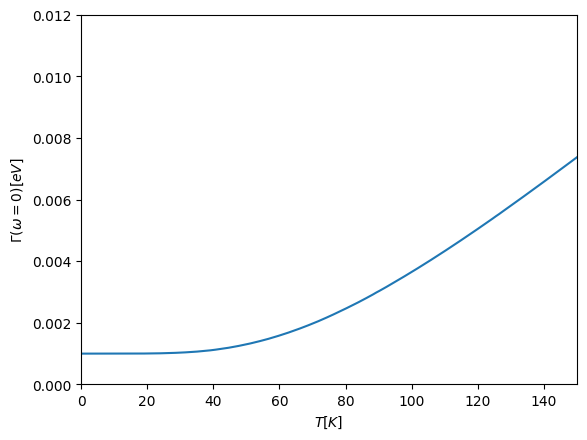

In [50]:
plt.plot(Ts, gammas_0)
plt.xlim([0, 150])
plt.ylim([0.00, 0.012])
plt.ylabel("$\Gamma(\omega=0) [eV]$")
plt.xlabel("$T [K]$")

**Akustični Drude**

In [15]:
def sigmas(w_vals, m1_vals, m2_vals, T):
    eff_conc = eff_concetration(T)
    return [(1j * eff_conc *e**2 *hbar / m / (w + m1 + 1j * (m2+Eta_0))).real for w, m1, m2 in zip(w_vals, m1_vals, m2_vals)]

def sigmas_drude(m2_vals, T):
    eff_conc = eff_concetration(T)
    return [eff_conc *e**2 *hbar / m / (m2+Eta_0) for m2 in m2_vals]

C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\2066699989.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for T in tqdm_notebook([20, 40, 60, 80, 100]):


  0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\4288499314.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return exp((-E + Ef) / (kb * T)) / (exp((-E + Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\4288499314.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (exp((E - Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\2663874110.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Text(0.5, 0, '$\\hbar \\omega [eV]$')

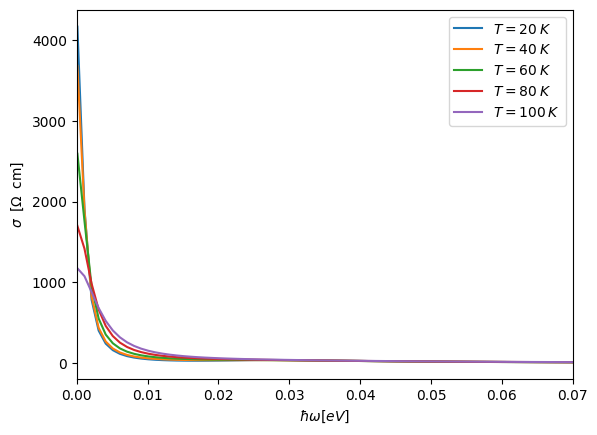

In [ ]:
results=[]
#dc = eff_concetration(300) / (mem_fn_ac(ss_sum_imag_ac, 0, hbar_w_ac_max, chemical_potential(300), T=300, eta=eta_0)+Eta_0)
for T in tqdm_notebook([20, 40, 60, 80, 100]):
    memfn = calculate_integral_points(mem_fn_ac, ss_sum_real_ac, ss_sum_imag_ac, hbar_w_ac_max, T=T, u = chemical_potential(T), eta=1*10**(-3))
    dynamic = 1 / 100 * 10**3 * np.array(sigmas(ws_0, memfn[0], memfn[1], T=T)) #/dc
    plt.plot(ws_0, dynamic, label=f"$T={T}\: K$")
    arrays_to_csv(ws_0, dynamic, f"sigma_T={T}K")
    results.append(dynamic)
plt.xlim([0, 0.07])
plt.legend()
plt.ylim([0,0.200])
plt.ylabel("$\sigma \:$ [$10^3 \cdot\Omega^{-1} \cdot$ cm$^{-1}$]")
plt.xlabel("$\hbar \omega [eV]$")

Text(0.5, 0, '$\\hbar \\omega [eV]$')

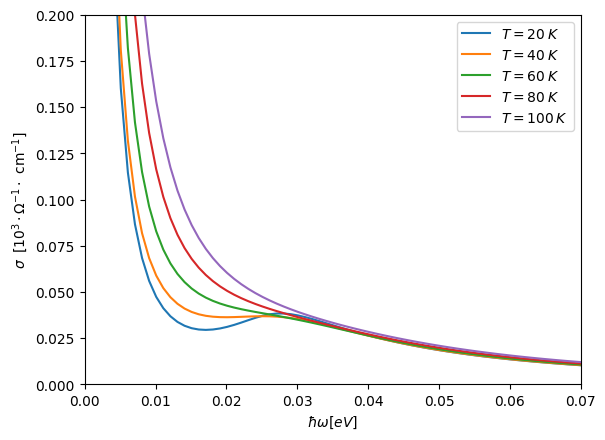

In [25]:
for i, T in enumerate([20, 40, 60, 80, 100]):
    plt.plot(ws_0, 1 / 1000 * results[i], label=f"$T={T}\: K$")
plt.xlim([0, 0.07])
plt.legend()
plt.ylim([0,0.200])
plt.ylabel("$\sigma \:$ [$10^3 \cdot\Omega^{-1} \cdot$ cm$^{-1}$]")
plt.xlabel("$\hbar \omega [eV]$")

C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\387791129.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for i,T in enumerate(tqdm_notebook([20, 40, 60, 80, 100])):


  0%|          | 0/5 [00:00<?, ?it/s]

Text(0.5, 0, '$\\hbar \\omega [eV]$')

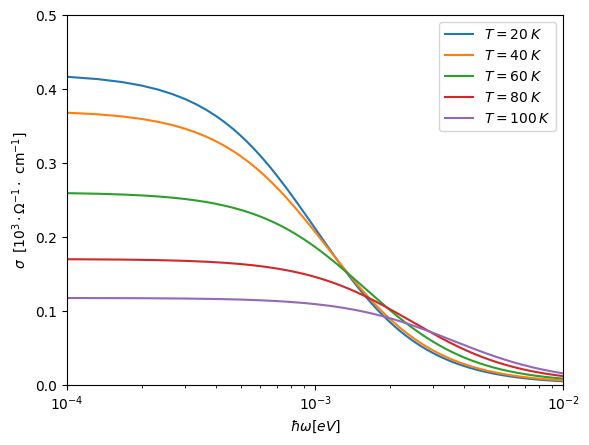

In [ ]:
results=[]
ws_log = ws=np.linspace(0.0001,0.01,300)
#dc = eff_concetration(300) / (mem_fn_ac(ss_sum_imag_ac, 0, hbar_w_ac_max, chemical_potential(300), T=300, eta=eta_0)+Eta_0)
for T in tqdm_notebook([20, 40, 60, 80, 100]):
    memfn = calculate_integral_points(mem_fn_ac, ss_sum_real_ac, ss_sum_imag_ac, hbar_w_ac_max, T=T, u = chemical_potential(T), eta=1*10**(-3), ws=ws_log)
    dynamic = 1 / 100 * 10**3 * np.array(sigmas(ws_log, memfn[0], memfn[1], T=T)) #/dc
    #dynamic = read_to_array(f"sigma_over_sigma_dc_T_small_omega={T}K.csv")[:,1]
    plt.plot(ws_log, dynamic, label=f"$T={T}\: K$")
    arrays_to_csv(ws_log, dynamic, f"sigma_T_small_omega={T}K")
    results.append(dynamic)
plt.xscale("log")
plt.legend()
plt.xlim([0.0002,0.01])
plt.ylim([0,5])
plt.ylabel("$\sigma \:$ [$10^3 \cdot\Omega^{-1} \cdot$ cm$^{-1}$]")
plt.xlabel("$\hbar \omega [eV]$")

**Ukupna vodljivost**

C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\3757626815.py:2: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for T in tqdm_notebook([20, 40, 60, 80, 100]):


  0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\4288499314.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return exp((-E + Ef) / (kb * T)) / (exp((-E + Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\4288499314.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (exp((E - Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\2663874110.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\Patrik\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


...

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

Text(0.5, 0, '$\\hbar \\omega [eV]$')

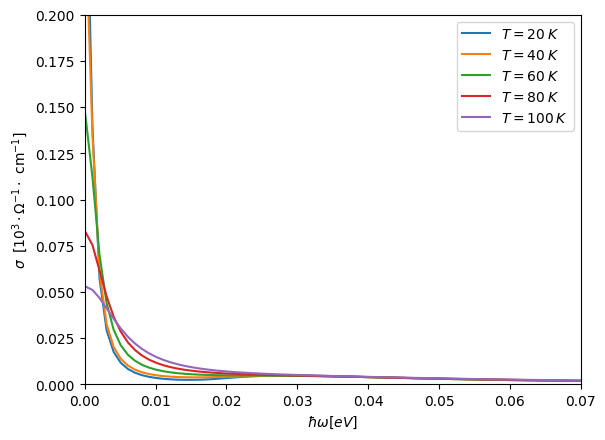

In [ ]:
results_uk=[]
for T in tqdm_notebook([20, 40, 60, 80, 100]):
    memfn_ac = calculate_integral_points(mem_fn_ac, ss_sum_real_ac, ss_sum_imag_ac, hbar_w_ac_max, T=T, u = chemical_potential(T), eta=1*10**(-3))
    memfn_op = calculate_integral_points(mem_fn_op, ss_sum_real, ss_sum_imag, hbar_op, T=T, u = chemical_potential(T), eta=eta_0)
    memfn = np.array(memfn_ac)+np.array(memfn_op)
    dynamic = 1 / 100 * 10**3 * np.array(sigmas(ws_0, memfn[0], memfn[1], T=T)) #/dc
    plt.plot(ws_0, dynamic, label=f"$T={T}\: K$")
    arrays_to_csv(ws_0, dynamic, f"sigma_uk_T={T}K")
    results_uk.append(dynamic)
plt.xlim([0, 0.07])
plt.legend()
plt.ylim([0,0.200])
plt.ylabel("$\sigma \:$ [$10^3 \cdot\Omega^{-1} \cdot$ cm$^{-1}$]")
plt.xlabel("$\hbar \omega [eV]$")

Text(0.5, 0, '$\\hbar \\omega [eV]$')

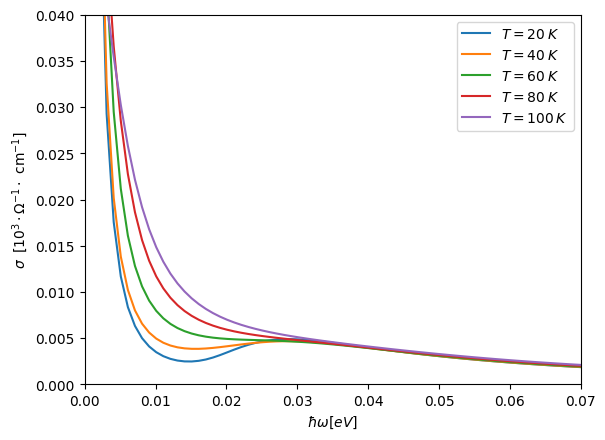

In [31]:
for i,T in enumerate([20, 40, 60, 80, 100]):
    plt.plot(ws_0, results_uk[i], label=f"$T={T}\: K$")
plt.xlim([0, 0.07])
plt.legend()
plt.ylim([0,0.0400])
plt.ylabel("$\sigma \:$ [$10^3 \cdot\Omega^{-1} \cdot$ cm$^{-1}$]")
plt.xlabel("$\hbar \omega [eV]$")

C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\3201659574.py:4: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for T in tqdm_notebook([20, 40, 60, 80, 100]):


  0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\4288499314.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return exp((-E + Ef) / (kb * T)) / (exp((-E + Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\4288499314.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return 1 / (exp((E - Ef) / (kb * T)) + 1)
C:\Users\Patrik\AppData\Local\Temp\ipykernel_7700\2663874110.py:12: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for w in tqdm_notebook(ws):


  0%|          | 0/300 [00:00<?, ?it/s]

c:\Users\Patrik\AppData\Local\Programs\Python\Python310\lib\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


...

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

Text(0.5, 0, '$\\hbar \\omega [eV]$')

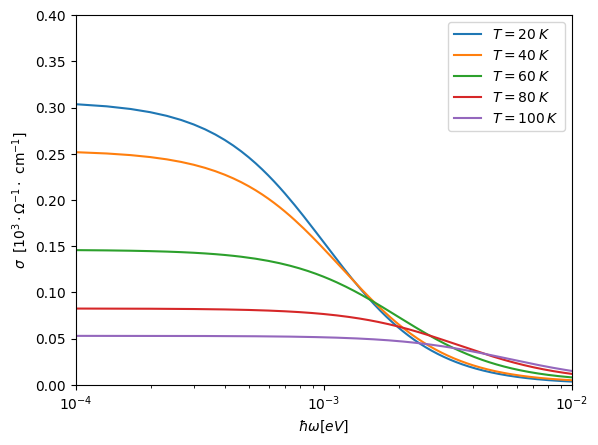

In [55]:
results_log=[]
ws_log = ws=np.linspace(0.0001,0.01,300)

for T in tqdm_notebook([20, 40, 60, 80, 100]):
    memfn_ac = calculate_integral_points(mem_fn_ac, ss_sum_real_ac, ss_sum_imag_ac, hbar_w_ac_max, T=T, u = chemical_potential(T), eta=eta_0, ws=ws_log)
    memfn_op = calculate_integral_points(mem_fn_op, ss_sum_real, ss_sum_imag, hbar_op, T=T, u = chemical_potential(T), eta=eta_0, ws=ws_log)
    memfn = np.array(memfn_ac)+np.array(memfn_op)
    dynamic = 1 / 100 * 10**3 * np.array(sigmas(ws_log, memfn[0], memfn[1], T=T)) #/dc
    #dynamic = read_to_array(f"sigma_over_sigma_dc_T_small_omega={T}K.csv")[:,1]
    plt.plot(ws_log, dynamic, label=f"$T={T}\: K$")
    arrays_to_csv(ws_log, dynamic, f"sigma_uk_T_small_omega={T}K")
    results.append(dynamic)
plt.xscale("log")
plt.legend()
plt.xlim([0.0001,0.01])
plt.ylim([0,0.4])
plt.ylabel("$\sigma \:$ [$10^3 \cdot\Omega^{-1} \cdot$ cm$^{-1}$]")
plt.xlabel("$\hbar \omega [eV]$")

(0.0, 0.35)

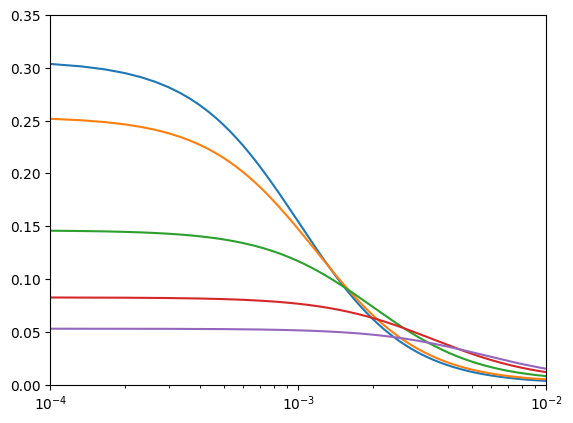

In [11]:
ws_log = ws=np.linspace(0.0001,0.01,300)
for i,T in enumerate([20, 40, 60, 80, 100]):
    dynamic = read_to_array(f"080925_novo//ac_op//sigma_uk_T_small_omega={T}K.csv")[:,1]
    plt.plot(ws_log, dynamic, label=f"$T={T}\: K$")
plt.xscale("log")
plt.xlim([0.0001,0.01])
plt.ylim([0,0.35])

**Usporedba sa i bez optičkih**

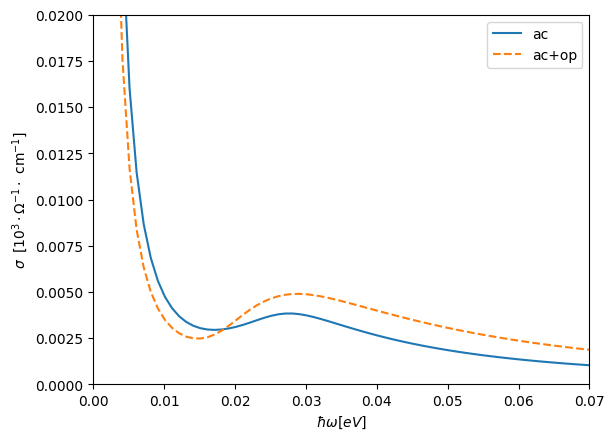

Text(0.5, 0, '$\\hbar \\omega [eV]$')

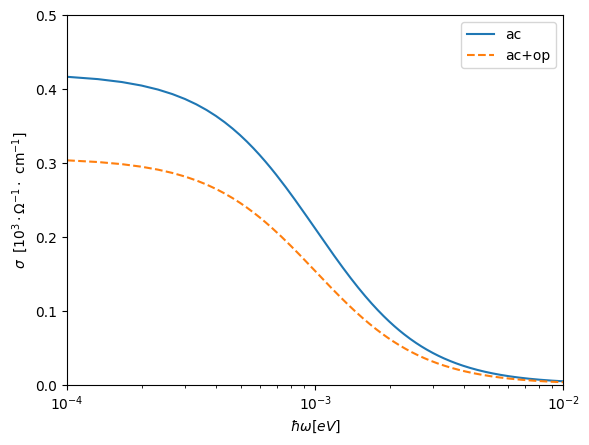

In [66]:
ac = read_to_array("sigma_T=20K.csv")*1/10000
ac_small = read_to_array("sigma_T_small_omega=20K.csv")
uk = read_to_array("sigma_uk_T=20K.csv")
uk_small = read_to_array("sigma_uk_T_small_omega=20K.csv")
plt.plot(ws_0, ac[:,1], label="ac")
plt.plot(ws_0, uk[:,1], label="ac+op", linestyle="--")
plt.xlim([0, 0.07])
plt.legend()
plt.ylim([0,0.0200])
plt.ylabel("$\sigma \:$ [$10^3 \cdot\Omega^{-1} \cdot$ cm$^{-1}$]")
plt.xlabel("$\hbar \omega [eV]$")
plt.show()
plt.plot(ws_log, ac_small[:,1], label="ac")
plt.plot(ws_log, uk_small[:,1], label="ac+op", linestyle="--")
plt.xscale("log")
plt.legend()
plt.xlim([0.0001,0.01])
plt.ylim([0,0.5])
plt.ylabel("$\sigma \:$ [$10^3 \cdot\Omega^{-1} \cdot$ cm$^{-1}$]")
plt.xlabel("$\hbar \omega [eV]$")

**Provjera**

In [ ]:
kup_gamma=pd.read_csv("kupcic_Gamma.txt", header=None)
plt.plot(kup_gamma[0], kup_gamma[1]/1000, label="K")

plt.plot(ws_0[1:],Gamma_for_m_values(ws_0[1:],integrals[0][1:], integrals[1][1:]),label="P", linestyle="--")
plt.ylim([0,0.014])
plt.xlim([0,0.06])
plt.legend()
plt.ylabel("$\Gamma(\omega)$")
plt.show()

kup_gamma_100=pd.read_csv("kupcic_Gamma_100.txt", header=None)
plt.plot(kup_gamma_100[0], kup_gamma_100[1]/1000, label="K")

plt.plot(ws_0[1:],Gamma_for_m_values(ws_0[1:],integrals_100[0][1:], integrals_100[1][1:]),label="P", linestyle="--")
plt.ylim([0,0.014])
plt.xlim([0,0.06])
plt.ylabel("$\Gamma(\omega)$")
plt.legend()
plt.show()


In [ ]:
kup_lambda=pd.read_csv("kupcic_lambda.txt", header=None)
plt.plot(kup_lambda[0], kup_lambda[1], label="K")

plt.plot(ws_0[1:],lambda_for_m_values(ws_0[1:],integrals[0][1:]),label="P", linestyle="--")
plt.xlim([0,0.06])
plt.legend()
plt.ylabel("$\lambda(\omega)$")
plt.show()

kup_lambda_100=pd.read_csv("kupcic_lambda_100.txt", header=None)
plt.plot(kup_lambda_100[0], kup_lambda_100[1], label="K")

plt.plot(ws_0[1:],lambda_for_m_values(ws_0[1:],integrals_100[0][1:]),label="P", linestyle="--")
plt.xlim([0,0.06])
plt.ylabel("$\lambda(\omega)$")
plt.legend()
plt.show()